<a href="https://colab.research.google.com/github/mathispernin/OSCD_ChangeDetection/blob/main/Copy_of_change_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Change Detection on OSCD - Visual Computing Project

This notebook implements and compares several unsupervised change detection algorithms on the OSCD dataset (Onera Satellite Change Detection).

## Project Objective
Compare the performance of several classical algorithms for urban change detection in satellite imagery on the OSCD dataset (CVA, PCA-Kmeans, IR-MAD, SiROC and IR-MAD with Graph Cuts).

## Train / Test Methodology

We use the OSCD dataset from Onera. We follow a validation protocol by splitting the 24 dataset locations into a training set (14 locations) and a test set (10 locations), so reported final metrics reflect unbiased generalization performance.
- **Train (14 locations)**: used to explore methods, compare approaches, and tune hyperparameters (thresholds, method parameters, etc.).
- **Test (10 locations)**: evaluate the final performance of selected methods on new data, using hyperparameters tuned on the training set.

In [1]:
# 1. Clone the repo to get the data/scripts
!git clone https://github.com/mathispernin/OSCD_ChangeDetection.git

# 2. Move into the repo directory so imports/paths work
import os
os.chdir('OSCD_ChangeDetection')

# 3. Install any libraries
!pip install -r requirements.txt

Cloning into 'OSCD_ChangeDetection'...
remote: Enumerating objects: 1632, done.
remote: Counting objects: 100% (13/13), done.
remote: Compressing objects: 100% (11/11), done.
remote: Total 1632 (delta 4), reused 7 (delta 2), pack-reused 1619 (from 2)
Receiving objects: 100% (1632/1632), 594.11 MiB | 33.16 MiB/s, done.
Resolving deltas: 100% (74/74), done.
Updating files: 100% (1449/1449), done.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 939.2/939.2 kB 14.6 MB/s eta 0:00:00 0:00:01


In [2]:
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## Configuration and Imports

In [4]:
# Imports standards
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch
import torch.nn.functional as F
from matplotlib import gridspec
from pathlib import Path
from typing import Tuple, List, Dict
from tqdm import tqdm

# Traitement d'images et données géospatiales
import rasterio
from rasterio.enums import Resampling
from PIL import Image

# ML et traitement statistique
import maxflow
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix
from scipy import linalg
from scipy.stats import chi2
from scipy.ndimage import median_filter, binary_opening, binary_closing
from skimage.filters import threshold_otsu, threshold_triangle
from skimage import morphology
from skimage.morphology import opening, closing, disk, remove_small_objects
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import HuberRegressor

# Suppression des warnings
import warnings
warnings.filterwarnings('ignore')

# Configuration matplotlib
plt.rcParams['figure.figsize'] = (15, 5)
plt.rcParams['font.size'] = 10

## Helper functions for data loading and processing

In [5]:
def radiometric_normalization(t1: np.ndarray, t2: np.ndarray) -> np.ndarray:
    """
    Apply a relative radiometric normalization between dates t1 and t2.

    Args:
        t1: Reference image (H, W, B).
        t2: Image to normalize (H, W, B).

    Returns:
        t2_norm: Normalized t2 image (H, W, B).
    """
    H, W, B = t1.shape
    t2_norm = np.zeros_like(t2)

    # 1. Spectral difference computation
    diff = np.linalg.norm(t2 - t1, axis=2)

    # 2. Select PIFs (10% of smallest differences)
    threshold = np.percentile(diff, 10)
    pif_mask = diff < threshold

    # 3. Linear regression per band
    for b in range(B):
        a, b_offset = np.polyfit(t2[pif_mask, b], t1[pif_mask, b], 1)
        t2_norm[:, :, b] = a * t2[:, :, b] + b_offset

    return t2_norm


def normalize_image(img: np.ndarray) -> np.ndarray:
    """Z-score normalization per band.

    Args:
        img: Image to normalize

    Returns:
        Normalized image
    """
    normalized = np.zeros_like(img)
    for b in range(img.shape[2]):
        band = img[:, :, b]
        normalized[:, :, b] = (band - band.mean()) / (band.std() + 1e-8)
    return normalized


def filter_by_area(change_map: np.ndarray, min_area_pixels: int = 100, max_area_pixels: int = None) -> np.ndarray:
    """
    Filter detected objects by their area (number of pixels).

    Args:
        change_map: Binary change map (H, W)
        min_area_pixels: Minimum area in pixels
        max_area_pixels: Maximum area in pixels

    Returns:
        Filtered map
    """
    labeled = morphology.label(change_map, connectivity=2)  # 8-connected

    filtered = np.zeros_like(change_map)
    for region_id in range(1, labeled.max() + 1):
        region_mask = labeled == region_id
        area = region_mask.sum()

        # Keep if within the desired range
        if area >= min_area_pixels:
            if max_area_pixels is None or area <= max_area_pixels:
                filtered[region_mask] = 1

    return filtered.astype(np.uint8)


In [6]:
class OSCDDataLoader:
    """DataLoader for the OSCD dataset."""

    def __init__(self, base_path: str, location: str = "rio"):
        self.base_path = Path(base_path) / location
        self.imgs_1_path = self.base_path / "imgs_1_rect"
        self.imgs_2_path = self.base_path / "imgs_2_rect"
        self.label_path = self.base_path / "cm" / "cm.png"
        # We use only the first 9 bands (10m and 20m resolution)
        self.useful_bands = ["B02", "B03", "B04", "B08"] + ["B05", "B06", "B07", "B11", "B12"]

    def read_and_resample(self, path: Path, target_shape: Tuple[int, int]) -> np.ndarray:
        """Read a TIFF file and resample it to the target resolution (10m)."""
        with rasterio.open(path) as src:
            data = src.read(
                out_shape=(src.count, target_shape[0], target_shape[1]),
                resampling=Resampling.bilinear
            )
            return data

    def load_multispectral_image(self, imgs_path: Path) -> np.ndarray:
        """Load and stack all useful bands."""
        # Reference: B04 (10m resolution) to determine target size
        ref_path = imgs_path / "B04.tif"
        with rasterio.open(ref_path) as ref:
            target_shape = (ref.height, ref.width)

        stack = []
        for band_name in self.useful_bands:
            band_path = imgs_path / f"{band_name}.tif"
            band_data = self.read_and_resample(band_path, target_shape)
            stack.append(band_data)

        img = np.concatenate(stack, axis=0)
        img = np.moveaxis(img, 0, -1)

        return img.astype(np.float32)

    def load_label(self) -> np.ndarray:
        """Load the binary change mask."""
        label_img = Image.open(self.label_path)
        label = np.array(label_img)

        # If multi-channel, check contents
        if label.ndim == 3:
            # If the first three channels are identical, keep one
            if np.array_equal(label[:, :, 0], label[:, :, 1]) and np.array_equal(label[:, :, 0], label[:, :, 2]):
                label = label[:, :, 0]
            else:
                raise ValueError("Mask channels are not identical.")

        return (label == 255).astype(np.uint8)

    def load_data(self) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
        """Load and prepare data (img1, img2, label)."""
        img1 = self.load_multispectral_image(self.imgs_1_path)
        img2 = self.load_multispectral_image(self.imgs_2_path)
        label = self.load_label()
        return img1, img2, label

    @staticmethod
    def get_all_locations(base_path: str) -> List[str]:
        """Return the list of all available locations in OSCD."""
        base = Path(base_path)
        locations = []
        for item in base.iterdir():
            if item.is_dir() and (item / "cm" / "cm.png").exists():
                locations.append(item.name)
        return sorted(locations)


### Train / Test split definition

The split follows the distribution proposed in the OSCD dataset reference paper:

- **Train (14 locations)**: aguasclaras, bercy, bordeaux, nantes, paris, rennes, saclay_e, abudhabi, cupertino, pisa, beihai, hongkong, beirut, mumbai
- **Test (10 locations)**: brasilia, montpellier, norcia, rio, saclay_w, valencia, dubai, lasvegas, milano, chongqing

In [7]:
# Définition du split Train / Test
TRAIN_LOCATIONS = [
    'aguasclaras', 'bercy', 'bordeaux', 'nantes', 'paris', 'rennes', 'saclay_e',
    'abudhabi', 'cupertino', 'pisa', 'beihai', 'hongkong', 'beirut', 'mumbai'
]
TEST_LOCATIONS = [
    'brasilia', 'montpellier', 'norcia', 'rio', 'saclay_w',
    'valencia', 'dubai', 'lasvegas', 'milano', 'chongqing'
]

In [8]:
base_path = "OSCD"
all_locations = OSCDDataLoader.get_all_locations(base_path)

print(f"{len(all_locations)} locations in total")
print(f"Train : {len(TRAIN_LOCATIONS)} locations ({TRAIN_LOCATIONS})")
print(f"Test  : {len(TEST_LOCATIONS)} locations ({TEST_LOCATIONS})")

24 locations in total
Train : 14 locations (['aguasclaras', 'bercy', 'bordeaux', 'nantes', 'paris', 'rennes', 'saclay_e', 'abudhabi', 'cupertino', 'pisa', 'beihai', 'hongkong', 'beirut', 'mumbai'])
Test  : 10 locations (['brasilia', 'montpellier', 'norcia', 'rio', 'saclay_w', 'valencia', 'dubai', 'lasvegas', 'milano', 'chongqing'])


In [9]:
# Exploration on a TRAIN example for visualization and data exploration
example_location = TRAIN_LOCATIONS[12] # beirut
print(f"Example location: {example_location}")

loader = OSCDDataLoader(base_path, example_location)
img1, img2, ground_truth = loader.load_data()

Example location: beirut


## Data Visualization

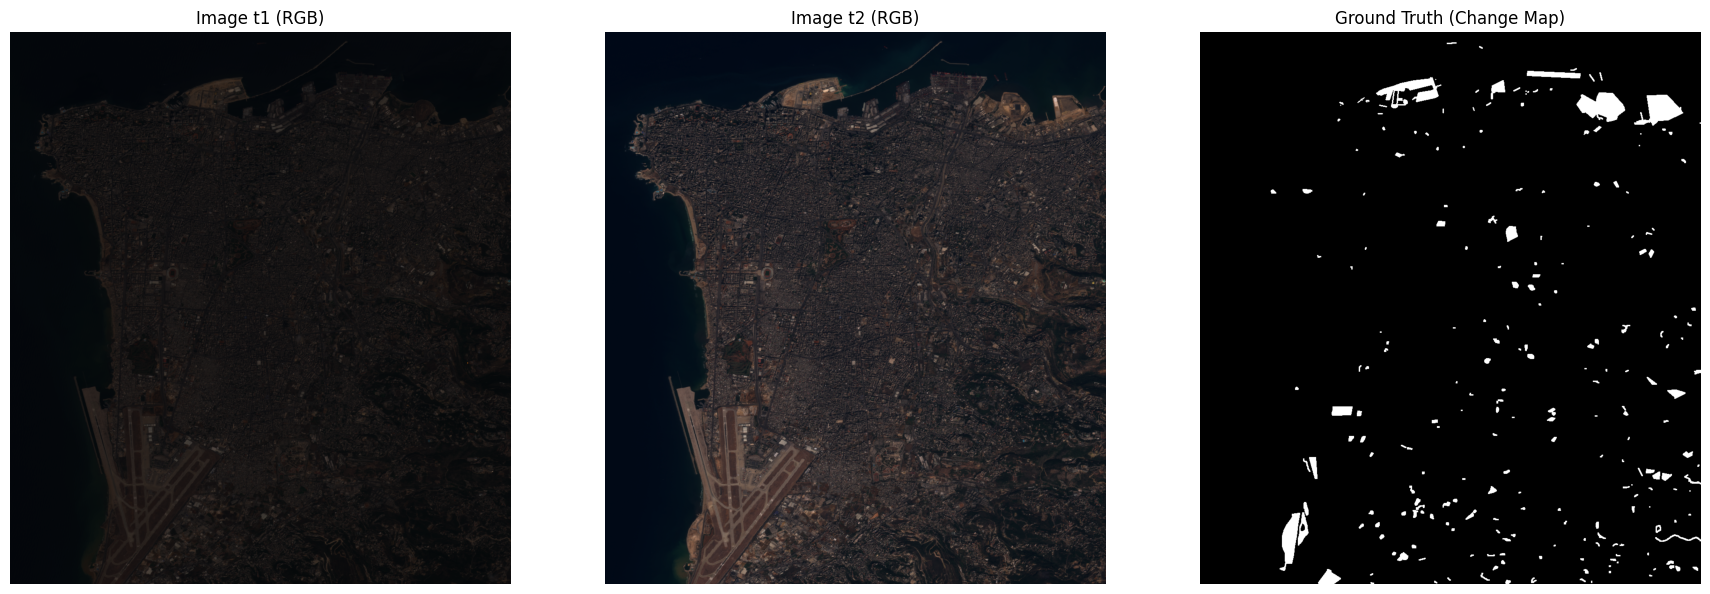

In [10]:
def visualize_data(img1: np.ndarray, img2: np.ndarray, label: np.ndarray):
    """Display RGB images and the ground truth mask."""
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    def to_rgb(img):
        rgb = img[:, :, [2, 1, 0]]
        rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-8)
        return np.clip(rgb, 0, 1)

    axes[0].imshow(to_rgb(img1))
    axes[0].set_title('Image t1 (RGB)')
    axes[0].axis('off')

    axes[1].imshow(to_rgb(img2))
    axes[1].set_title('Image t2 (RGB)')
    axes[1].axis('off')

    axes[2].imshow(label * 255, cmap='gray')
    axes[2].set_title('Ground Truth (Change Map)')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

visualize_data(img1, img2, ground_truth)

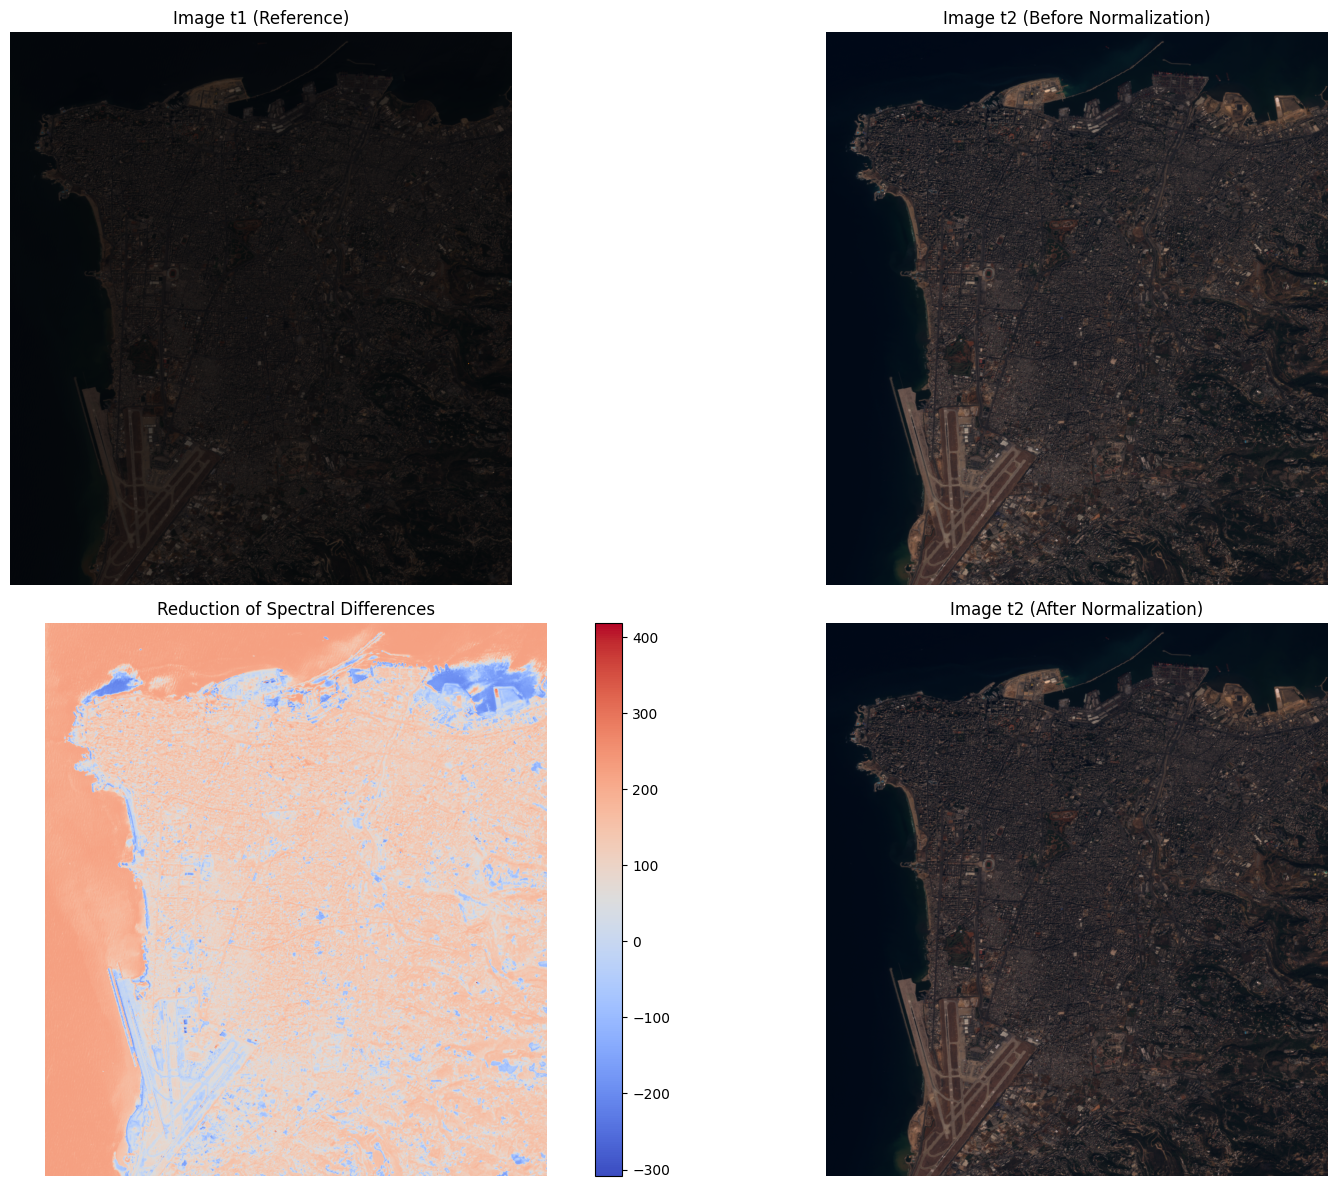

In [11]:
def visualize_radiometric_normalization(t1: np.ndarray, t2: np.ndarray):
    """
    Visualize the effect of relative radiometric normalization (RRN).

    Args:
        t1: Reference image (H, W, B).
        t2: Image to normalize (H, W, B).
    """
    # Apply radiometric normalization
    t2_norm = radiometric_normalization(t1, t2)

    # Compute spectral differences before and after normalization
    diff_before = np.linalg.norm(t2 - t1, axis=2)
    diff_after = np.linalg.norm(t2_norm - t1, axis=2)

    # Visualization
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))

    def to_rgb(img):
        rgb = img[:, :, [2, 1, 0]]
        rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-8)
        return np.clip(rgb, 0, 1)

    # Show t1 (reference)
    axes[0, 0].imshow(to_rgb(t1))
    axes[0, 0].set_title('Image t1 (Reference)')
    axes[0, 0].axis('off')

    # Show t2 before normalization
    axes[0, 1].imshow(to_rgb(t2))
    axes[0, 1].set_title('Image t2 (Before Normalization)')
    axes[0, 1].axis('off')

    # Show the reduction in spectral differences
    im3 = axes[1, 0].imshow(diff_before - diff_after, cmap='coolwarm')
    axes[1, 0].set_title('Reduction of Spectral Differences')
    axes[1, 0].axis('off')
    fig.colorbar(im3, ax=axes[1, 0])

    # Show t2 normalized
    axes[1, 1].imshow(to_rgb(t2_norm))
    axes[1, 1].set_title('Image t2 (After Normalization)')
    axes[1, 1].axis('off')


    plt.tight_layout()
    plt.show()

# Example usage
visualize_radiometric_normalization(img1, img2)

## Algorithm 1: PCA-Kmeans

In [12]:
class PCAKmeans:
    """PCA for denoising + K-means for binary clustering."""

    def __init__(self, n_components: int = 3):
        """
        Args:
            n_components: Number of principal components to keep
        """
        self.n_components = n_components
        self.pca = PCA(n_components=n_components)

    def detect(self, img1: np.ndarray, img2: np.ndarray) -> np.ndarray:
        """Compute binary change map using PCA + K-means."""
        # Normalization
        img2 = radiometric_normalization(img1, img2)
        img1 = normalize_image(img1)
        img2 = normalize_image(img2)

        # Difference image
        diff = img2 - img1
        H, W, C = diff.shape
        diff_flat = diff.reshape(-1, C)

        # PCA
        diff_pca = self.pca.fit_transform(diff_flat)

        # K-means clustering (k=2)
        kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
        labels = kmeans.fit_predict(diff_pca)

        # Identify the "change" cluster: the one with larger variance
        cluster_0_var = diff_pca[labels == 0].var()
        cluster_1_var = diff_pca[labels == 1].var()
        change_label = 0 if cluster_0_var > cluster_1_var else 1
        change_map = (labels == change_label).reshape(H, W).astype(np.uint8)

        # Post-processing to remove noise
        structElement = morphology.disk(1)
        change_map = morphology.binary_opening(change_map, structElement)
        change_map = morphology.binary_closing(change_map, structElement)
        change_map = filter_by_area(change_map, min_area_pixels=25)

        return change_map


## Algorithm 2: CVA (Change Vector Analysis)

In [13]:
class CVA:
    """Change Vector Analysis"""

    def __init__(self):
        self.threshold = None
        self.magnitude = None

    def detect(self, img1: np.ndarray, img2: np.ndarray) -> np.ndarray:
        """Compute binary change map using the CVA method."""
        # Use only the first 4 bands (10m resolution)
        img1 = img1[:, :, :4]
        img2 = img2[:, :, :4]

        # Normalization
        img2 = radiometric_normalization(img1, img2)
        img1 = normalize_image(img1)
        img2 = normalize_image(img2)

        # Compute change vector magnitude
        diff = img2 - img1
        self.magnitude = np.sqrt(np.sum(diff**2, axis=2))

        # Median filtering to reduce noise
        self.magnitude = median_filter(self.magnitude, size=5)

        # Thresholding and binarization
        #self.threshold = threshold_otsu(self.magnitude)
        #self.threshold = np.percentile(self.magnitude, 90)
        self.threshold = threshold_triangle(self.magnitude)
        change_map = (self.magnitude > self.threshold).astype(np.uint8)

        # Post-processing to remove noise
        change_map = binary_opening(change_map, structure=np.ones((3,3))).astype(np.uint8)
        change_map = binary_closing(change_map, structure=np.ones((3,3))).astype(np.uint8)
        change_map = filter_by_area(change_map, min_area_pixels=25)

        return change_map


## Algorithm 3: IR-MAD

In [14]:
class IRMAD:
    """Iteratively Reweighted Multivariate Alteration Detection (IR-MAD)"""

    def __init__(self, niter: int = 10):
        """
        Args:
            niter: Number of IR-MAD iterations
        """
        self.niter = niter
        self.chi2_dist = None
        self.mad_variates = None
        self.pvs = None

    @staticmethod
    def np_weight_stats(x: np.ndarray, ws: np.ndarray = None) -> tuple:
        """
        Compute weighted mean and covariance.

        Args:
            x: Data matrix (N, D)
            ws: Weight vector (N,)

        Returns:
            (wsigma, wmean): Weighted covariance and weighted mean
        """
        if ws is None or not np.any(ws):
            ws = np.ones(x.shape[0])
        mean = np.ma.average(x, axis=0, weights=ws)
        wmean = np.expand_dims(mean.data, axis=1)
        wsigma = np.cov(x, rowvar=False, aweights=ws)
        return wsigma, wmean

    def apply_maf(self, mads: np.ndarray, width: int, height: int) -> np.ndarray:
        """
        Apply the MAF (Maximum Autocorrelation Factor) transform to MAD variates.

        Args:
            mads: MAD variates (N_pixels, N_bands)
            width: Image width
            height: Image height

        Returns:
            MAF-transformed variates (N_pixels, N_bands), sorted by decreasing autocorrelation.
        """
        N_bands = mads.shape[1]
        img = mads.reshape(height, width, N_bands) # (H, W, C)

        # Compute spatial differences
        diff_h = img[:, :-1, :] - img[:, 1:, :]
        diff_v = img[:-1, :, :] - img[1:, :, :]
        data_diff = np.vstack((
            diff_h.reshape(-1, N_bands),
            diff_v.reshape(-1, N_bands)
        ))

        # Covariance matrices
        sigma_delta = np.cov(data_diff, rowvar=False)
        sigma_mad = np.cov(mads, rowvar=False)

        # Solve generalized eigenproblem
        evals, evecs = linalg.eigh(sigma_delta, sigma_mad)

        return mads @ evecs

    def detect(self, img1: np.ndarray, img2: np.ndarray, threshold_percentage: float = 96, use_maf: bool = False) -> np.ndarray:
        """
        Compute binary change map using the IR-MAD method.

        Args:
            img1: t1 image (H, W, C)
            img2: t2 image (H, W, C)
            threshold_percentage: Percentile for change threshold (e.g. 96 for the top 4% most changing)
            use_maf: Apply MAF transform to MAD variates to improve detection

        Returns:
            Binary change map (H, W)
        """
        # Use only the first 4 bands (10m resolution)
        img1 = img1[:, :, :4]
        img2 = img2[:, :, :4]

        H, W, C = img1.shape
        N = C
        m = H * W

        im1r = img1.reshape(m, N)
        im2r = img2.reshape(m, N)
        x = np.concatenate((im1r, im2r), axis=1)

        # Initialize uniform weights
        pvs = np.ones(m, dtype=np.float32)

        for itr in tqdm(range(self.niter), desc="IR-MAD iterations"):
            # Compute weighted statistics
            sigma, mean = self.np_weight_stats(x, pvs)

            ms1 = mean[:N].T  # mean image 1
            ms2 = mean[N:].T  # mean image 2

            # Block covariance matrices
            reg = 1 * np.eye(N) # regularization
            sigma11 = sigma[:N, :N] + reg
            sigma12 = sigma[:N, N:]
            sigma21 = sigma[N:, :N]
            sigma22 = sigma[N:, N:] + reg

            # Solve generalized eigenvalue problems
            A1 = sigma12 @ np.linalg.solve(sigma22, sigma12.T)
            A2 = sigma12.T @ np.linalg.solve(sigma11, sigma12)
            lamda1, eigvec1 = linalg.eigh(A1, sigma11)
            lamda2, eigvec2 = linalg.eigh(A2, sigma22)

            # Sort by descending eigenvalue
            idx1 = np.argsort(lamda1)[::-1]
            lamda1 = lamda1[idx1]
            eigvec1 = eigvec1[:, idx1]
            idx2 = np.argsort(lamda2)[::-1]
            lamda2 = lamda2[idx2]
            eigvec2 = eigvec2[:, idx2]

            # Canonical correlations
            rho2 = lamda1
            rho = np.sqrt(np.clip(rho2, 0, 1))

            # Ensure positive correlation between canonical variate pairs
            diag = np.diag(eigvec1.T @ sigma12 @ eigvec2)
            signs = np.diag(diag / (np.abs(diag) + 1e-10))
            eigvec2 = eigvec2 @ signs

            # Compute MAD variates
            sig2s = 2 * (1 - rho)
            sig2s = np.tile(sig2s, (m, 1))  # (m, N)
            ms1_tile = np.tile(ms1[0], (m, 1))  # (m, N)
            ms2_tile = np.tile(ms2[0], (m, 1))  # (m, N)

            # Canonical variates
            cv1 = (im1r - ms1_tile) @ eigvec1
            cv2 = (im2r - ms2_tile) @ eigvec2
            mads = cv1 - cv2

            # Chi-square distance
            chisqr = np.sum(np.square(mads) / (sig2s + 1e-10), axis=1)

            # Update weights (p-values)
            pvs = 1 - chi2(N).cdf(chisqr)
            pvs = pvs.squeeze()
            pvs = np.clip(pvs, 1e-10, 1.0)

        if use_maf:
            mads = self.apply_maf(mads, W, H)
            mads = mads[:, :4]
            chisqr = np.sum(np.square(mads), axis=1)
        else:
            chisqr = np.sum(np.square(mads) / (sig2s + 1e-10), axis=1)

        self.mad_variates = mads
        self.chi2_dist = chisqr.reshape(H, W)
        self.pvs = pvs.reshape(H, W)

        # Morphological smoothing on chi2 to reduce noise before thresholding
        structElement = morphology.disk(1)
        chi2_smooth = morphology.opening(self.chi2_dist, structElement)

        # Thresholding
        threshold = np.percentile(chi2_smooth, threshold_percentage)
        change_map = (chi2_smooth > threshold).astype(np.uint8)

        # Light binary post-processing to remove small objects
        change_map = morphology.binary_closing(change_map, structElement)
        change_map = filter_by_area(change_map, min_area_pixels=75)

        return change_map


## Algorithm 4: SiROC

In [15]:
class SiROC:
    """
    Our implementation of SiROC (Spectral Regression for Change Detection) with robust global regression
    and accumulation of spectral differences across a set of low-order polynomials.
    """

    def __init__(self, s=1, n_max=4, min_area=25):
        """
        Args:
            s: step for polynomial degrees
            n_max: maximum polynomial degree to test
            min_area: minimum area in pixels
        """
        self.s = s
        self.n_max = n_max
        self.min_area = min_area
        self.uncertainty_map = None

    @staticmethod
    def _normalize(img):
        """Z-score normalization per band."""
        img = img.astype(np.float32)
        for b in range(img.shape[2]):
            mu = img[:, :, b].mean()
            std = img[:, :, b].std() + 1e-6
            img[:, :, b] = (img[:, :, b] - mu) / std
        return img

    def _apply_hsr(self, I_t, I_t1, degree):
        """Robust global "sibling" regression for a given polynomial degree."""
        H, W, B = I_t.shape
        I_hat = np.zeros_like(I_t)

        for b in range(B):
            x = I_t[:, :, b].reshape(-1, 1)
            y = I_t1[:, :, b].reshape(-1)

            poly = PolynomialFeatures(degree=degree, include_bias=True)
            X_poly = poly.fit_transform(x)

            reg = HuberRegressor(
                epsilon=1.35,
                alpha=0.0,
                max_iter=200
            )
            reg.fit(X_poly, y)

            y_hat = reg.predict(X_poly)
            I_hat[:, :, b] = y_hat.reshape(H, W)

        return I_hat

    def detect(self, img1, img2):
        """Compute binary change map using our SiROC implementation."""
        # Normalization
        img1 = self._normalize(img1)
        img2 = self._normalize(img2)

        H, W, _ = img1.shape
        self.uncertainty_map = np.zeros((H, W), dtype=np.float32)

        # Ensemble of low-order polynomials with step s
        for degree in range(1, self.n_max, self.s):
            I_hat = self._apply_hsr(img1, img2, degree)
            diff = np.sum(np.abs(I_hat - img2), axis=2)
            self.uncertainty_map += diff

        # Otsu thresholding and binarization
        th = threshold_otsu(self.uncertainty_map)
        change_map = (self.uncertainty_map > th)

        # Post-processing to remove noise
        se = disk(1)
        change_map = opening(change_map, se)
        change_map = closing(change_map, se)
        change_map = remove_small_objects(change_map, self.min_area)

        return change_map.astype(np.uint8)


In [16]:
class SiROCFast:
    """Optimized version of SiROC with local regression using convolutions to speed-up neighborhood sums."""

    def __init__(
        self,
        max_neighborhood: int = 200,
        splits: int = 27,
        ensemble: bool = True,
        morph_operations: bool = True,
        mp_start: int = 5,
        mp_stop: int = 6,
        mp_step: int = 1,
        manual_otsu_factor: float = 1.0
    ):
        """
        Args:
            max_neighborhood: Maximum neighborhood size for local regression
            splits: Number of splits for the ensemble of neighborhoods
            ensemble: Use an ensemble or a single neighborhood
            morph_operations: Morphological filtering to reduce noise
            mp_start, mp_stop, mp_step: Parameters for neighborhood splits
            manual_otsu_factor: Multiplicative factor to adjust Otsu threshold
        """
        self.max_neighborhood = max_neighborhood
        self.splits = splits
        self.ensemble = ensemble
        self.morph_operations = morph_operations

        self.mp_start = mp_start
        self.mp_stop = mp_stop
        self.mp_step = mp_step

        self.manual_otsu_factor = manual_otsu_factor
        self.voting_threshold, self.auto_otsu_factor = self._call_voting_parameters()
        self.otsu_factor = self.manual_otsu_factor if self.manual_otsu_factor else self.auto_otsu_factor

        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    def _call_voting_parameters(self):
        """Initialize voting parameters for ensemble neighborhoods."""
        if self.morph_operations:
            return 0.5, 1.0
        return 0.35, 0.75 if self.ensemble else 0.65

    @staticmethod
    def normalize_input(img):
        """Z-score normalization per band."""
        return (img - img.mean()) / (img.std() + 1e-8)

    def _split_neighborhood_uniform(self, neighborhood, splits, excluded):
        """Split the neighborhood uniformly into several splits for the ensemble."""
        splitted = []
        step = max(1, (neighborhood - excluded) // splits)
        for i in range(1, splits + 1):
            local_n = step * i + excluded
            ex = step * (i - 1) + excluded
            splitted.append((local_n, ex))
        return splitted

    def _separable_box_sum(self, img_tensor, radius):
        """
        Compute the sum of pixels in a square neighborhood of size (2*radius+1) x (2*radius+1)
        efficiently using separable convolutions.
        Complexity: O(radius) instead of O(radius^2) for naive sum.
        """
        if radius <= 0:
            return img_tensor

        kernel_size = 2 * radius + 1
        channels = img_tensor.shape[1]

        # Vertical pass (column neighborhood sum)
        k_y = torch.ones((channels, 1, kernel_size, 1), device=self.device)
        pad_y = F.pad(img_tensor, (0, 0, radius, radius), mode='replicate')
        temp = F.conv2d(pad_y, k_y, groups=channels)

        # Horizontal pass (row neighborhood sum)
        k_x = torch.ones((channels, 1, 1, kernel_size), device=self.device)
        pad_x = F.pad(temp, (radius, radius, 0, 0), mode='replicate')
        return F.conv2d(pad_x, k_x, groups=channels)

    def _obtain_change_map(self, pre, post, neighborhood, excluded=0):
        """Compute the change map for a given neighborhood using a fast local regression."""
        pre_response = pre ** 2
        post_response = pre * post

        # Outer sum for both images
        pre_sum_big = self._separable_box_sum(pre_response, neighborhood)
        post_sum_big = self._separable_box_sum(post_response, neighborhood)

        # Subtract smaller sums if excluding part of the neighborhood
        if excluded > 0:
            pre_sum_small = self._separable_box_sum(pre_response, excluded)
            post_sum_small = self._separable_box_sum(post_response, excluded)

            pre_sum = pre_sum_big - pre_sum_small
            post_sum = post_sum_big - post_sum_small
        else:
            pre_sum = pre_sum_big
            post_sum = post_sum_big

        epsilon = 1e-6
        ratio_map = post_sum / (pre_sum + epsilon)
        post_pred = pre * ratio_map
        return torch.abs(post_pred - post), ratio_map

    def detect(self, img1: np.ndarray, img2: np.ndarray, debug=False) -> np.ndarray:
        """Compute binary change map using our optimized SiROC implementation."""
        img1_norm = self.normalize_input(img1)
        img2_norm = self.normalize_input(img2)

        # Move to GPU
        t1 = torch.from_numpy(img1_norm).permute(2, 0, 1).float().unsqueeze(0).to(self.device)
        t2 = torch.from_numpy(img2_norm).permute(2, 0, 1).float().unsqueeze(0).to(self.device)

        if self.ensemble:
            neighborhoods = self._split_neighborhood_uniform(self.max_neighborhood, self.splits, 0)
            raw_maps = []
            binary_maps = []
            debug_ratio = None

            for i, (n, ex) in enumerate(neighborhoods):
                c_map_tensor, ratio = self._obtain_change_map(t1, t2, n, ex) # on GPU
                c_map = c_map_tensor.squeeze(0).mean(dim=0).cpu().numpy()

                # For debugging, keep the ratio map of the middle split
                if debug and i == len(neighborhoods)//2:
                    debug_ratio = ratio.squeeze(0).mean(dim=0).cpu().numpy()
                
                c_map = np.nan_to_num(c_map)
                raw_maps.append(c_map)

                # Normalization & Otsu thresholding
                mi, ma = c_map.min(), c_map.max()
                c_map_norm = (c_map - mi) / (ma - mi) if ma > mi else np.zeros_like(c_map)
                val_for_otsu = (c_map_norm * 255).astype(np.uint8)
                t_otsu = cv2.threshold(val_for_otsu, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[0]
                binary = (c_map_norm > (t_otsu * self.otsu_factor / 255)).astype(np.float32)

                # Morphological filtering to reduce noise
                if self.morph_operations:
                    morph_profile = np.zeros_like(binary)
                    count = 0
                    for kernel_size in range(self.mp_start, self.mp_stop, self.mp_step):
                        kernel = np.ones((kernel_size, kernel_size), np.uint8)
                        closed = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)
                        opened = cv2.morphologyEx(closed, cv2.MORPH_OPEN, kernel)
                        morph_profile += opened
                        count += 1
                    if count > 0:
                        binary = morph_profile / count

                binary_maps.append(binary)

            vote_map = np.mean(binary_maps, axis=0)
            final_map = (vote_map >= self.voting_threshold).astype(np.uint8)

            if debug:
                # Return a vote map to visualize ensemble effect
                return final_map, np.mean(raw_maps, axis=0), debug_ratio, vote_map

        return final_map


## Algorithm 5: IR-MAD with Graph Cuts (spatial regularization)

In [17]:
def graph_cut_mrf_regularization(chi2_map: np.ndarray, threshold: float, beta: float = 1.0) -> np.ndarray:
    """
    Graph Cuts based MRF regularization.

    Args:
        chi2_map: IR-MAD Chi² distance map [H, W]
        threshold: Separation threshold for change / no-change
        beta: Weight of spatial regularization term

    Returns:
        Binary change map (1 = change, 0 = no-change)

    Principle:
        Minimize energy E = E_data + E_smooth where:
        - E_data: penalizes misclassified pixels according to their chi² value
        - E_smooth: penalizes spatial discontinuities (encourages homogeneity)
    """
    # Model energy parameters
    E_max = 10.0 # Max energy to avoid divergence
    alpha = 0.0000001 # Controls width of uncertainty zone

    # Adaptive thresholds around the threshold
    mu_s = threshold + (1.0 / alpha) ** 0.5  # center of change class
    mu_t = threshold - (1.0 / alpha) ** 0.5  # center of no-change class

    # Data term
    E_source = alpha * (mu_s - chi2_map) ** 2 # Energy for "change" label (Source)
    E_source = np.clip(E_source, 0, E_max)
    E_source[chi2_map > mu_s] = 0 
    E_sink = alpha * (mu_t - chi2_map) ** 2 # Energy for "no-change" label (Sink)
    E_sink = np.clip(E_sink, 0, E_max)
    E_sink[chi2_map < mu_t] = 0 

    # Build graph
    g = maxflow.Graph[float]()
    nodeids = g.add_grid_nodes(chi2_map.shape)

    # T-links: terminal connections (Source/Sink)
    g.add_grid_tedges(nodeids, E_sink, E_source)

    # N-links: neighbor connections (4-connected)
    g.add_grid_edges(nodeids, beta) # beta controls strength of spatial regularization

    # Max-Flow / Min-Cut optimization
    g.maxflow()

    # Retrieve segmentation
    segments = g.get_grid_segments(nodeids)

    # Invert: 1 = change, 0 = no-change
    change_map = np.logical_not(segments).astype(np.uint8)

    # Filter small objects
    change_map = filter_by_area(change_map, min_area_pixels=100, max_area_pixels=50000)

    return change_map

Test with different beta parameters:



IR-MAD iterations: 100%|██████████| 10/10 [00:05<00:00,  1.86it/s]


Beta=0.1: 27292 pixels detected as change (2.2%)
 F1=0.5299, Precision=0.5943, Recall=0.4782

Beta=1.0: 26403 pixels detected as change (2.1%)
 F1=0.5493, Precision=0.6275, Recall=0.4885

Beta=5.0: 28948 pixels detected as change (2.3%)
 F1=0.5691, Precision=0.6180, Recall=0.5274

Beta=10.0: 22656 pixels detected as change (1.8%)
 F1=0.5923, Precision=0.7395, Recall=0.4939



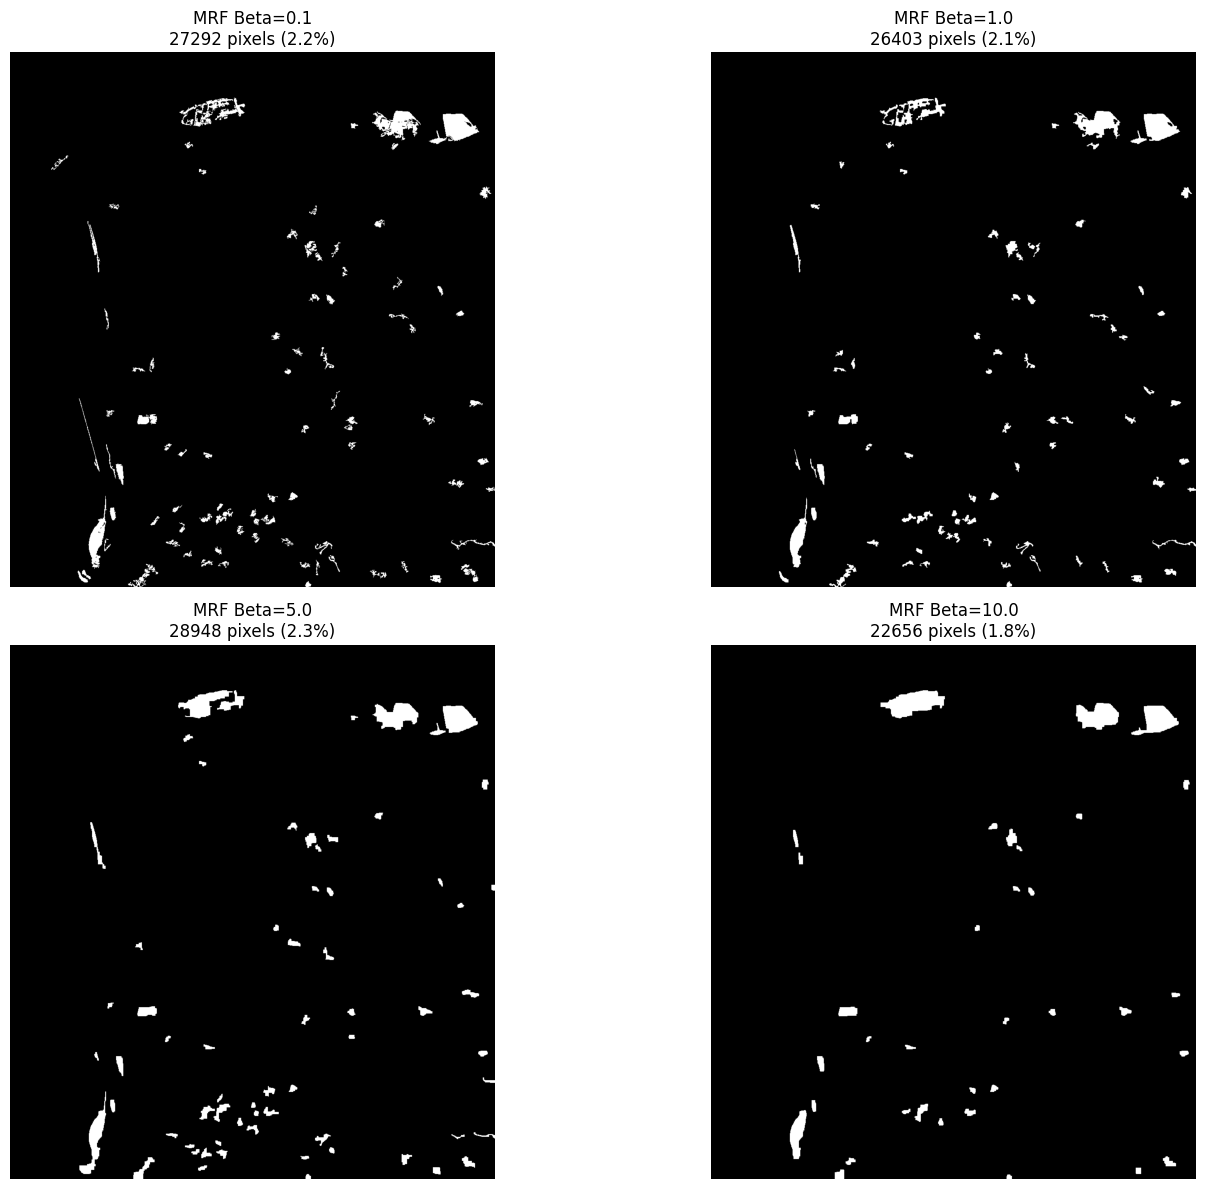

In [18]:
print("Test with different beta parameters:\n")

irmad = IRMAD(niter=10)
_ = irmad.detect(img1, img2, threshold_percentage=95, use_maf=False)
threshold = np.percentile(irmad.chi2_dist, 90)

# Test different beta values
beta_values = [0.1, 1.0, 5.0, 10.0]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, beta in enumerate(beta_values):
    mrf_result = graph_cut_mrf_regularization(irmad.chi2_dist, threshold, beta)
    n_changes = mrf_result.sum()
    pct_changes = 100 * n_changes / mrf_result.size

    # Compute metrics
    f1 = f1_score(ground_truth.flatten(), mrf_result.flatten())
    precision = precision_score(ground_truth.flatten(), mrf_result.flatten())
    recall = recall_score(ground_truth.flatten(), mrf_result.flatten())
    print(f"Beta={beta}: {n_changes} pixels detected as change ({pct_changes:.1f}%)")
    print(f" F1={f1:.4f}, Precision={precision:.4f}, Recall={recall:.4f}\n")

    # Visualization
    axes[idx].imshow(mrf_result, cmap='gray')
    axes[idx].set_title(f'MRF Beta={beta}\n{n_changes} pixels ({pct_changes:.1f}%)')
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

## Methods Evaluation

In [19]:
class ChangeDetectionEvaluator:
    """Evaluator for change detection methods."""

    @staticmethod
    def compute_metrics(pred: np.ndarray, gt: np.ndarray) -> Dict[str, float]:
        """Compute performance metrics."""
        pred_flat = pred.flatten()
        gt_flat = gt.flatten()

        metrics = {
            'Precision': precision_score(gt_flat, pred_flat, zero_division=0),
            'Recall': recall_score(gt_flat, pred_flat, zero_division=0),
            'F1-Score': f1_score(gt_flat, pred_flat, zero_division=0),
        }

        # Confusion matrix
        tn, fp, fn, tp = confusion_matrix(gt_flat, pred_flat).ravel()
        metrics['TN'] = tn
        metrics['FP'] = fp
        metrics['FN'] = fn
        metrics['TP'] = tp

        return metrics

    @staticmethod
    def print_metrics(method_name: str, metrics: Dict[str, float]):
        """Print metrics summary."""
        print(f"\n{'='*50}")
        print(f"Method: {method_name}")
        print(f"{'='*50}")
        print(f"F1-Score: {metrics['F1-Score']:.4f}")
        print(f"Precision: {metrics['Precision']:.4f}")
        print(f"Recall: {metrics['Recall']:.4f}")
        print(f"TP: {metrics['TP']}, FP: {metrics['FP']}, FN: {metrics['FN']}, TN: {metrics['TN']}")

In [20]:
def visualize_change_maps(ground_truth: np.ndarray, **change_maps):
    """
    Visualize produced binary change maps.

    Args:
        ground_truth: Reference binary change map.
        change_maps: Dictionary containing binary change maps (name -> map).
    """
    n_rows, n_cols = 2, 4
    fig = plt.figure(figsize=(24, 12))
    gs = gridspec.GridSpec(n_rows, n_cols, width_ratios=[1, 1, 1, 1])

    # Ground Truth occupies both rows of the first column (centered vertically)
    ax_gt = fig.add_subplot(gs[:, 0])
    ax_gt.imshow(ground_truth * 255, cmap='gray')
    ax_gt.set_title('Ground Truth', fontsize=22)
    ax_gt.axis('off')

    # The other maps
    method_axes = []
    for i in range(1, n_cols):
        for j in range(n_rows):
            method_axes.append(fig.add_subplot(gs[j, i]))

    for ax, (method_name, change_map) in zip(method_axes, change_maps.items()):
        ax.imshow(change_map * 255, cmap='gray')
        ax.set_title(method_name, fontsize=22)
        ax.axis('off')

    plt.tight_layout()
    plt.show()


## Example detection on one image

In [21]:
# Compute change maps for different methods
cva = CVA() 
cva_result = cva.detect(img1, img2) 

pca_kmeans = PCAKmeans(n_components=3) 
pca_kmeans_result = pca_kmeans.detect(img1, img2) 

irmad = IRMAD(niter=10) 
irmad_result = irmad.detect(img1, img2, threshold_percentage=96, use_maf=False) 

irmad = IRMAD(niter=10)
_ = irmad.detect(img1, img2, threshold_percentage=95, use_maf=False)
irmad_mrf_result = graph_cut_mrf_regularization(irmad.chi2_dist,threshold=np.percentile(irmad.chi2_dist, 90), beta=0.5)

siroc = SiROC(s=1, n_max=4, min_area=25) 
siroc_result = siroc.detect(img1, img2) 

siroc_fast = SiROCFast(max_neighborhood=200, splits=27, ensemble=True, morph_operations=True) 
siroc_fast_result = siroc_fast.detect(img1, img2)

IR-MAD iterations: 100%|██████████| 10/10 [00:06<00:00,  1.62it/s]


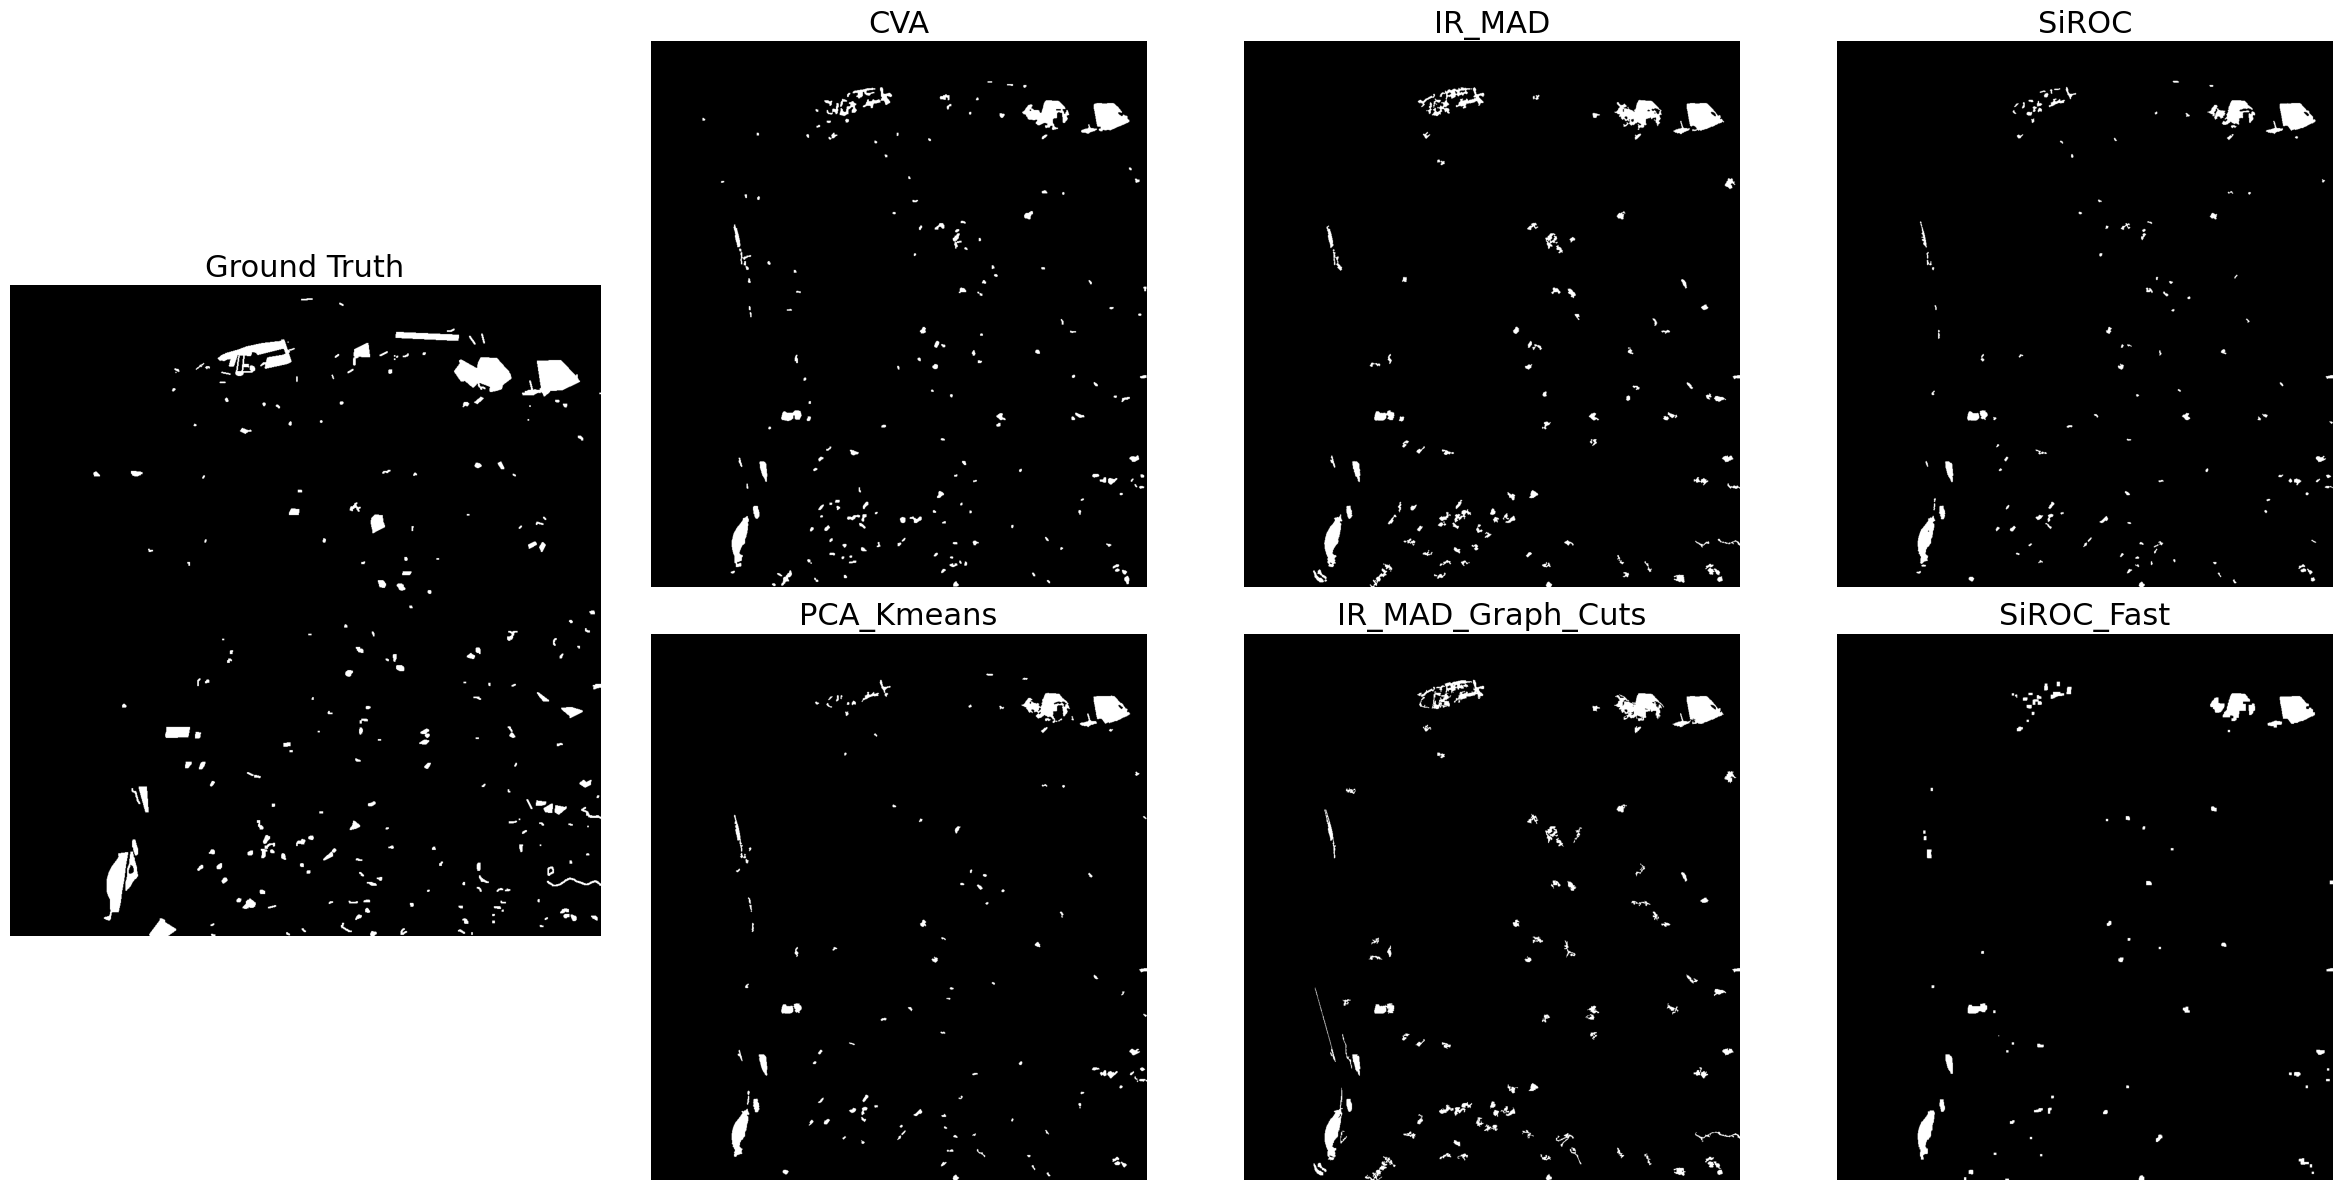

In [22]:
visualize_change_maps(
    ground_truth,
    CVA=cva_result,
    PCA_Kmeans=pca_kmeans_result,
    IR_MAD=irmad_result,
    IR_MAD_Graph_Cuts=irmad_mrf_result,
    SiROC=siroc_result,
    SiROC_Fast=siroc_fast_result
)

In [23]:
# Evaluate all methods on the example image
evaluator = ChangeDetectionEvaluator()

results = {
    'CVA': cva_result,
    'PCA-Kmeans': pca_kmeans_result,
    'IR-MAD': irmad_result,
    'IR-MAD + Graph Cuts': irmad_mrf_result,
    'SiROC': siroc_result,
    'SiROC Fast': siroc_fast_result
}

metrics_summary = {}
for method_name, prediction in results.items():
    metrics = evaluator.compute_metrics(prediction, ground_truth)
    metrics_summary[method_name] = metrics
    evaluator.print_metrics(method_name, metrics)


Method: CVA
F1-Score: 0.5782
Precision: 0.7104
Recall: 0.4876
TP: 16537, FP: 6742, FN: 17381, TN: 1221940

Method: PCA-Kmeans
F1-Score: 0.5316
Precision: 0.7945
Recall: 0.3994
TP: 13548, FP: 3505, FN: 20370, TN: 1225177

Method: IR-MAD
F1-Score: 0.5529
Precision: 0.6540
Recall: 0.4789
TP: 16245, FP: 8596, FN: 17673, TN: 1220086

Method: IR-MAD + Graph Cuts
F1-Score: 0.5482
Precision: 0.6283
Recall: 0.4862
TP: 16491, FP: 9758, FN: 17427, TN: 1218924

Method: SiROC
F1-Score: 0.5320
Precision: 0.8097
Recall: 0.3962
TP: 13437, FP: 3158, FN: 20481, TN: 1225524

Method: SiROC Fast
F1-Score: 0.5010
Precision: 0.8532
Recall: 0.3546
TP: 12027, FP: 2070, FN: 21891, TN: 1226612


## Training set optimization

We run all methods on the 14 training locations to compare approaches and validate our parameter choices. Hyperparameters (thresholds, morphological filter sizes, regularization parameters, etc.) were tuned solely based on training set results.

In [24]:
def process_locations(base_path: str, locations: List[str], methods_to_run: List[str] = None, label: str = ""):
    """
    Process a list of locations and compute metrics.

    Args:
        base_path: Path to the OSCD dataset
        locations: List of locations to process
        methods_to_run: List of methods to run
        label: Label ("TRAIN", "TEST")
    """
    if methods_to_run is None:
        methods_to_run = ['CVA', 'PCA-Kmeans', 'IR-MAD', 'IR-MAD+GC', 'SiROC']

    print(f"{'='*70}")
    print(f" {label} — {len(locations)} locations")
    print(f"{'='*70}")
    print(f"Locations: {locations}")
    print(f"Methods: {methods_to_run}")

    # Store results
    all_metrics = {method: [] for method in methods_to_run}
    evaluator = ChangeDetectionEvaluator()

    for idx, location in enumerate(locations):
        print(f"\n{'='*70}")
        print(f"[{idx+1}/{len(locations)}] Processing: {location} ({label})")
        print(f"{'='*70}")

        # Load data
        loader = OSCDDataLoader(base_path, location)
        img1, img2, ground_truth = loader.load_data()
        results_location = {}

        # CVA
        if 'CVA' in methods_to_run:
            print("CVA...")
            cva = CVA()
            results_location['CVA'] = cva.detect(img1, img2)

        # PCA-Kmeans
        if 'PCA-Kmeans' in methods_to_run:
            print("PCA-Kmeans...")
            pca_kmeans = PCAKmeans(n_components=2)
            results_location['PCA-Kmeans'] = pca_kmeans.detect(img1, img2)

        # IR-MAD
        if 'IR-MAD' in methods_to_run:
            print("IR-MAD...")
            irmad = IRMAD(niter=10)
            results_location['IR-MAD'] = irmad.detect(img1, img2, threshold_percentage=96, use_maf=True)

        # IR-MAD + Graph Cuts
        if 'IR-MAD+GC' in methods_to_run:
            print("IR-MAD + Graph Cuts...")
            irmad = IRMAD(niter=10)
            _ = irmad.detect(img1, img2, threshold_percentage=95, use_maf=False)
            results_location['IR-MAD+GC'] = graph_cut_mrf_regularization(
                irmad.chi2_dist,
                threshold=np.percentile(irmad.chi2_dist, 90),
                beta=0.5
            )

        # SiROC (our implementation)
        if 'SiROC' in methods_to_run:
            print("SiROC...") 
            siroc_ours = SiROC(
                s=1,
                n_max=4,
                min_area=25
            )
            results_location['SiROC'] = siroc_ours.detect(img1, img2)

        # SiROCFast (GPU optimized implementation)
        if 'SiROCFast' in methods_to_run:
            print("SiROC (optimized)...")
            siroc = SiROCFast(
                ensemble=True,
                morph_operations=True,
                max_neighborhood=200,
                splits=27,
                manual_otsu_factor=1.0
            )
            results_location['SiROCFast'] = siroc.detect(img1, img2)
        
        # Compute metrics
        for method_name, prediction in results_location.items():
            metrics = evaluator.compute_metrics(prediction, ground_truth)
            all_metrics[method_name].append(metrics)

    return all_metrics, locations

In [25]:
def compute_aggregate_metrics(all_metrics: Dict[str, List[Dict]]) -> pd.DataFrame:
    """Compute aggregate statistics across images for each method."""
    summary = {}

    for method_name, metrics_list in all_metrics.items():
        if len(metrics_list) == 0:
            continue

        f1_scores = [m['F1-Score'] for m in metrics_list]
        precisions = [m['Precision'] for m in metrics_list]
        recalls = [m['Recall'] for m in metrics_list]

        summary[method_name] = {
            'F1-Score (mean)': np.mean(f1_scores),
            'F1-Score (std)': np.std(f1_scores),
            'Precision (mean)': np.mean(precisions),
            'Precision (std)': np.std(precisions),
            'Recall (mean)': np.mean(recalls),
            'Recall (std)': np.std(recalls),
            'N images': int(len(metrics_list))
        }

    return pd.DataFrame(summary).T

In [26]:
# Run on the TRAIN set
train_metrics, train_processed = process_locations(
    base_path,
    locations=TRAIN_LOCATIONS,
    methods_to_run=['PCA-Kmeans', 'CVA', 'IR-MAD', 'IR-MAD+GC', 'SiROC', 'SiROCFast'],
    label="TRAIN",
)

 TRAIN — 14 locations
Locations: ['aguasclaras', 'bercy', 'bordeaux', 'nantes', 'paris', 'rennes', 'saclay_e', 'abudhabi', 'cupertino', 'pisa', 'beihai', 'hongkong', 'beirut', 'mumbai']
Methods: ['PCA-Kmeans', 'CVA', 'IR-MAD', 'IR-MAD+GC', 'SiROC', 'SiROCFast']

[1/14] Processing: aguasclaras (TRAIN)
CVA...
PCA-Kmeans...
IR-MAD...


IR-MAD iterations: 100%|██████████| 10/10 [00:01<00:00,  9.67it/s]


IR-MAD + Graph Cuts...


IR-MAD iterations: 100%|██████████| 10/10 [00:01<00:00,  9.61it/s]


SiROC...
SiROC (optimized)...

[2/14] Processing: bercy (TRAIN)
CVA...
PCA-Kmeans...
IR-MAD...


...

SiROC...
SiROC (optimized)...

[14/14] Processing: mumbai (TRAIN)
CVA...
PCA-Kmeans...
IR-MAD...


IR-MAD iterations: 100%|██████████| 10/10 [00:01<00:00,  5.31it/s]


IR-MAD + Graph Cuts...


IR-MAD iterations: 100%|██████████| 10/10 [00:01<00:00,  5.32it/s]


SiROC...
SiROC (optimized)...


In [27]:
# TRAIN set results
df_train_summary = compute_aggregate_metrics(train_metrics)

print("="*100)
print("RESULTS — TRAIN SET (14 locations)")
print("="*100)
print(df_train_summary.to_string())

RESULTS — TRAIN SET (14 locations)
            F1-Score (mean)  F1-Score (std)  Precision (mean)  Precision (std)  Recall (mean)  Recall (std)  N images
PCA-Kmeans         0.098208        0.132017          0.120799         0.230861       0.368539      0.216939      14.0
CVA                0.325862        0.173396          0.318271         0.184626       0.405802      0.187651      14.0
IR-MAD             0.303005        0.151857          0.333757         0.190957       0.317796      0.120435      14.0
IR-MAD+GC          0.304912        0.164580          0.287965         0.161921       0.365727      0.187240      14.0
SiROC              0.245129        0.174141          0.242408         0.230826       0.463779      0.196147      14.0
SiROCFast          0.170902        0.180186          0.181418         0.249660       0.557357      0.319140      14.0


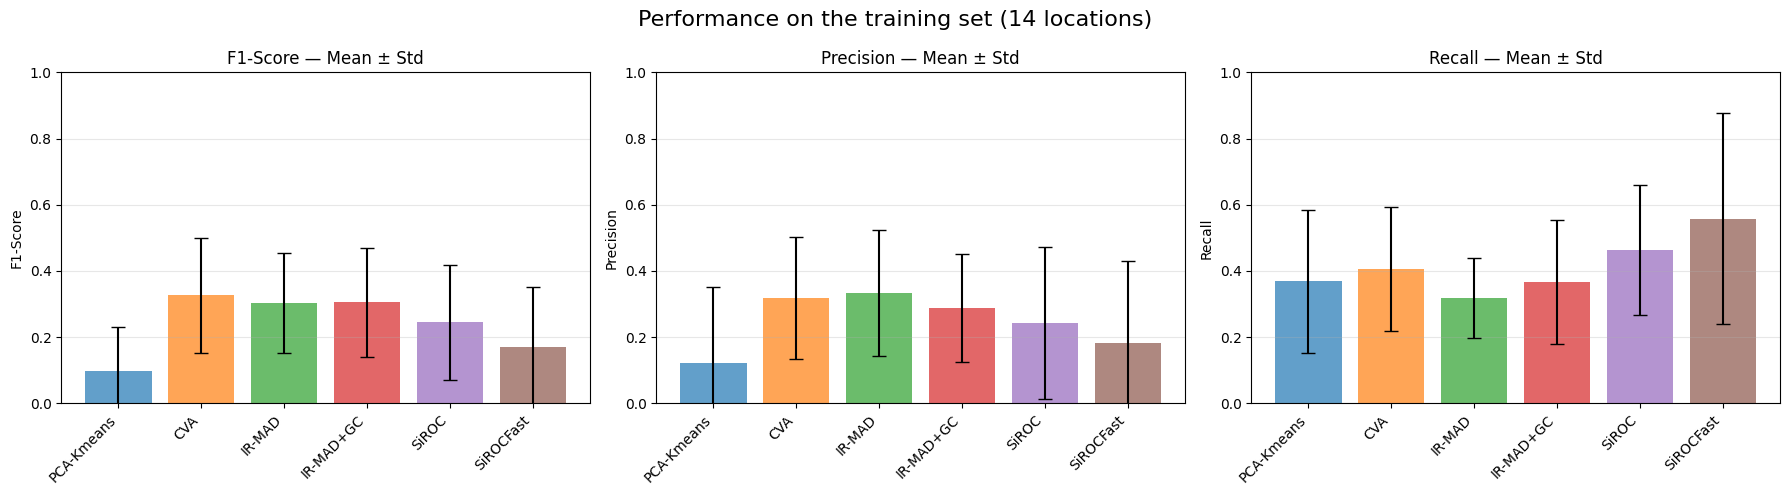

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Performance on the training set (14 locations)", fontsize=16)

metrics_names = ['F1-Score', 'Precision', 'Recall']
axes_flat = axes.flatten()

for idx, metric in enumerate(metrics_names):
    ax = axes_flat[idx]
    means = df_train_summary[f'{metric} (mean)'].values
    stds = df_train_summary[f'{metric} (std)'].values
    methods = df_train_summary.index.tolist()

    x_pos = np.arange(len(methods))
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b'][:len(methods)] 
    ax.bar(x_pos, means, yerr=stds, capsize=5, alpha=0.7, color=colors)
    ax.set_ylabel(metric)
    ax.set_title(f'{metric} — Mean ± Std')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(methods, rotation=45, ha='right')
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

## Final Results

In [29]:
# Final evaluation on the TEST set (10 locations)

test_metrics, test_processed = process_locations(
    base_path,
    locations=TEST_LOCATIONS,
    methods_to_run=['PCA-Kmeans', 'CVA', 'IR-MAD', 'IR-MAD+GC', 'SiROC', 'SiROCFast'],
    label="TEST"
)

 TEST — 10 locations
Locations: ['brasilia', 'montpellier', 'norcia', 'rio', 'saclay_w', 'valencia', 'dubai', 'lasvegas', 'milano', 'chongqing']
Methods: ['PCA-Kmeans', 'CVA', 'IR-MAD', 'IR-MAD+GC', 'SiROC', 'SiROCFast']

[1/10] Processing: brasilia (TEST)
CVA...
PCA-Kmeans...
IR-MAD...


IR-MAD iterations: 100%|██████████| 10/10 [00:00<00:00, 11.95it/s]


IR-MAD + Graph Cuts...


IR-MAD iterations: 100%|██████████| 10/10 [00:00<00:00, 11.99it/s]


SiROC...
SiROC (optimized)...

[2/10] Processing: montpellier (TEST)
CVA...
PCA-Kmeans...
IR-MAD...


...

SiROC...
SiROC (optimized)...

[10/10] Processing: chongqing (TEST)
CVA...
PCA-Kmeans...
IR-MAD...


IR-MAD iterations: 100%|██████████| 10/10 [00:01<00:00,  6.31it/s]


IR-MAD + Graph Cuts...


IR-MAD iterations: 100%|██████████| 10/10 [00:01<00:00,  5.72it/s]


SiROC...
SiROC (optimized)...


In [30]:
# Aggregated results on the TEST set
df_test_summary = compute_aggregate_metrics(test_metrics)

print("\n" + "="*100)
print("FINAL RESULTS — TEST SET (10 locations)")
print("="*100)
print(df_test_summary.to_string())


FINAL RESULTS — TEST SET (10 locations)
            F1-Score (mean)  F1-Score (std)  Precision (mean)  Precision (std)  Recall (mean)  Recall (std)  N images
PCA-Kmeans         0.199911        0.233844          0.192734         0.267696       0.462055      0.124854      10.0
CVA                0.346073        0.235490          0.371931         0.256144       0.381583      0.231316      10.0
IR-MAD             0.314791        0.180555          0.501103         0.341798       0.279371      0.144418      10.0
IR-MAD+GC          0.359912        0.231773          0.406168         0.294526       0.399321      0.189730      10.0
SiROC              0.319506        0.244992          0.311365         0.264988       0.447167      0.161222      10.0
SiROCFast          0.311811        0.254928          0.265770         0.242958       0.610466      0.220436      10.0


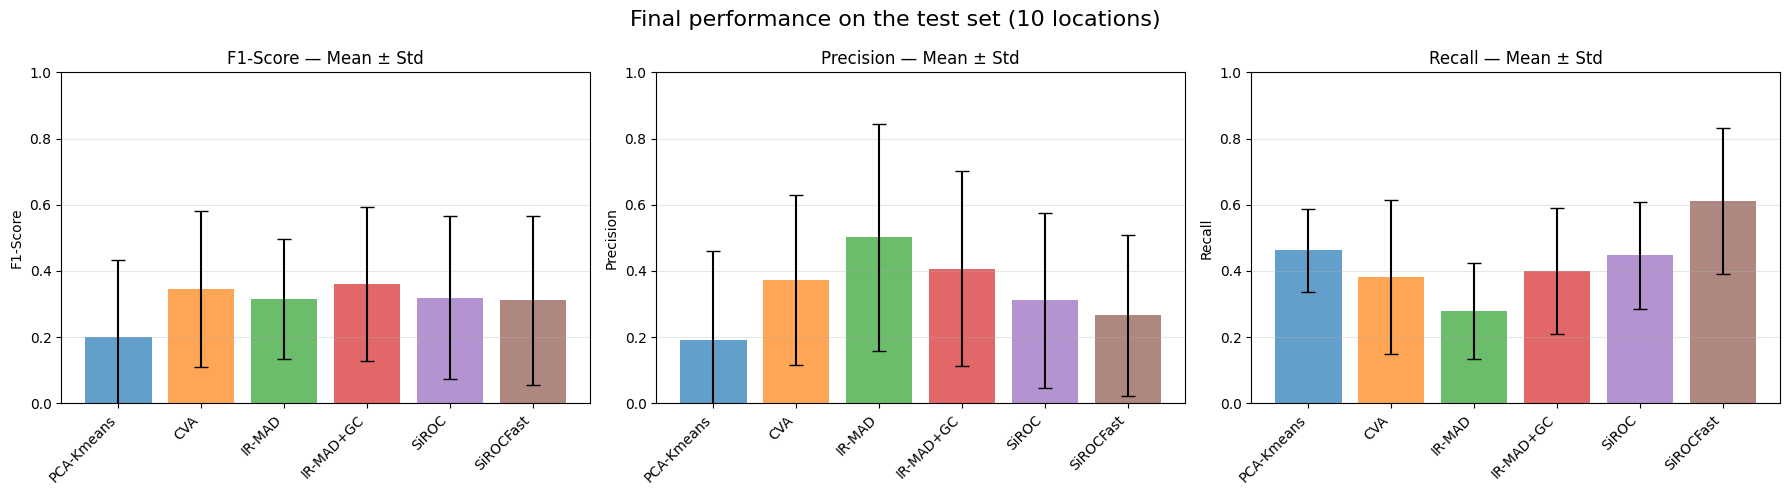

In [31]:
# Comparative plot — Test set (error bars)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Final performance on the test set (10 locations)", fontsize=16)

metrics_names = ['F1-Score', 'Precision', 'Recall']
axes_flat = axes.flatten()

for idx, metric in enumerate(metrics_names):
    ax = axes_flat[idx]

    means = df_test_summary[f'{metric} (mean)'].values
    stds = df_test_summary[f'{metric} (std)'].values
    methods = df_test_summary.index.tolist()

    x_pos = np.arange(len(methods))
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b'][:len(methods)]
    ax.bar(x_pos, means, yerr=stds, capsize=5, alpha=0.7, color=colors)
    ax.set_ylabel(metric)
    ax.set_title(f'{metric} — Mean ± Std')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(methods, rotation=45, ha='right')
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

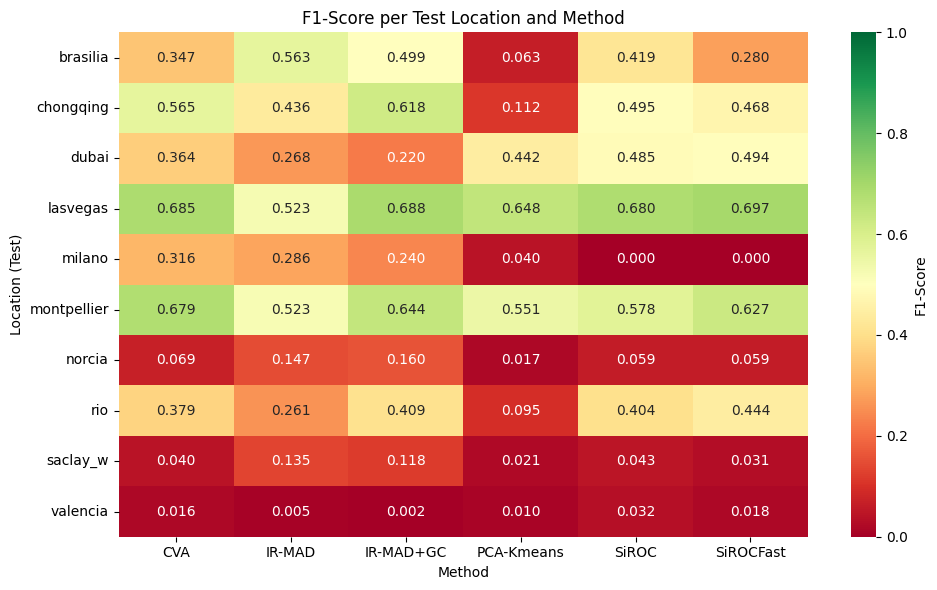

In [33]:
# Detailed results per test location
detailed_test_results = []
for method_name, metrics_list in test_metrics.items():
    for idx, metrics in enumerate(metrics_list):
        detailed_test_results.append({
            'Location': test_processed[idx],
            'Method': method_name,
            'F1-Score': metrics['F1-Score'],
            'Precision': metrics['Precision'],
            'Recall': metrics['Recall']
        })

df_test_detailed = pd.DataFrame(detailed_test_results)

# Heatmap F1-Score per test location and method
pivot_f1_test = df_test_detailed.pivot(index='Location', columns='Method', values='F1-Score')
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_f1_test, annot=True, fmt='.3f', cmap='RdYlGn', vmin=0, vmax=1, cbar_kws={'label': 'F1-Score'})
plt.title('F1-Score per Test Location and Method')
plt.xlabel('Method')
plt.ylabel('Location (Test)')
plt.tight_layout()
plt.show()